# Evaluación 3
Integrante 1: Leandro flores

Integrante 2: Pablo Águila

Integrante 3: Pablo Saavedra

Correo Electrónico integrante 1: leandro.flores2201@alumnos.ubiobio.cl

Correo Electrónico integrante 2: pablo.aguila1901@alumnos.ubiobio.cl

Correo Electrónico integrante 3: pablo.saavedra2201@alumnos.ubiobio.cl

Fecha de Creación: Junio de 2026
Versión: 1.1

# Descripción
Este notebook presenta el desarrollo de la Evaluación 3 correspondiente a la asignatura de Inteligencia Artificial, perteneciente a la carrera de Ingeniería Civil en Informática de la Universidad del Bío-Bío, sede Concepción.
El propósito es construir, optimizar y evaluar modelos de clasificación binaria (LogisticRegression y DecisionTreeClassifier) orientados a detectar transacciones fraudulentas en la fintech PaySecure, ajustando el umbral de decisión para equilibrar la precisión y el recall de acuerdo al contexto del negocio.

# Requisitos de Software
Este notebook fue desarrollado con Python 3.12. A continuación se listan las bibliotecas necesarias:

pandas (>=1.5.0)
numpy (>=1.23.0)
matplotlib (>=3.6.0)
seaborn (>=0.12.0)
scikit-learn (>=1.2.0)
Para verificar la versión instalada ejecutar usando el siguiente comando, usando la librería de la cual quieres saber la versión:

import pandas as pd
print(pd.__version__)

In [1]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

from sklearn.inspection import permutation_importance
from sklearn.tree import plot_tree

from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, FunctionTransformer, StandardScaler

from sklearn.base import BaseEstimator, TransformerMixin

In [2]:
# Descarga del dataset desde el repositorio
!wget -q https://raw.githubusercontent.com/Pablo-Saave/Proyecto_Inteligencia_Artificial.2/refs/heads/main/data/ingestion/data_fraude.csv

data = pd.read_csv('data_fraude.csv')

print(f'Dimensiones del dataset: {data.shape}')
print(f'Filas: {data.shape[0]} | Columnas: {data.shape[1]}')
data.head()

Dimensiones del dataset: (20000, 15)
Filas: 20000 | Columnas: 15


,transaction_amount,account_balance,transaction_time_seconds,avg_transaction_amount_7d,std_transaction_amount_7d,transactions_last_1h,transactions_last_24h,failed_attempts,num_devices_used,transaction_type,device_type,location_region,is_foreign_transaction,is_high_risk_country,is_fraud
0,199.333714,0.000000,70488,62.541060,41.484248,5,15,1,2,transfer,mobile,rural,1,0,1
1,33.534123,2687.259698,1594,73.618027,20.889169,0,10,0,1,withdrawal,mobile,rural,0,0,0
2,7.607833,1766.666482,60663,75.790821,27.265759,0,5,0,3,purchase,tablet,rural,0,0,0
3,144.069650,1402.597270,32332,61.424568,28.104612,0,15,0,3,withdrawal,mobile,suburban,0,0,0
4,60.279300,193.506482,49575,53.153535,1.000000,3,10,0,1,withdrawal,desktop,rural,0,0,0


Variable objetivo

In [3]:
target = "is_fraud"

Empezaremos a comprender los datos

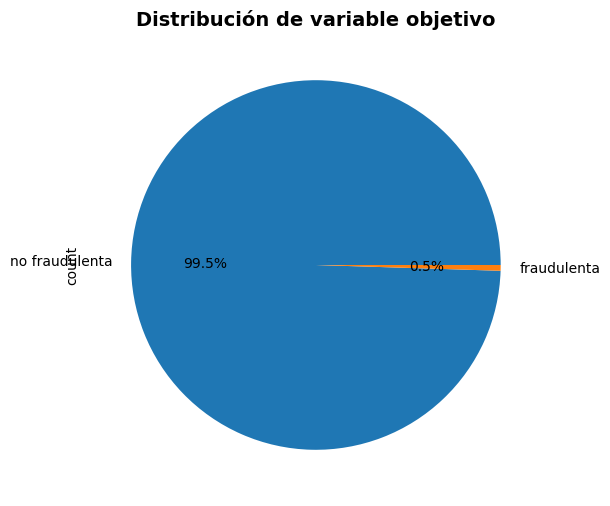

In [4]:
data[target].value_counts().plot(kind='pie', autopct='%1.1f%%',
                                 labels=['no fraudulenta', 'fraudulenta'],
                                 figsize=(6, 6))
plt.title("Distribución de variable objetivo", fontsize=14, fontweight="bold")
plt.show()

Si, hay sesgo.

In [5]:
data.dtypes

,0
transaction_amount,float64
account_balance,float64
transaction_time_seconds,int64
avg_transaction_amount_7d,float64
std_transaction_amount_7d,float64
transactions_last_1h,int64
transactions_last_24h,int64
failed_attempts,int64
num_devices_used,int64
transaction_type,object


In [6]:
inconsistentes = data[(data["transaction_amount"] < 0) |
 (data["account_balance"] <= 0) | (data["transaction_time_seconds"] < 0) |
  (data["avg_transaction_amount_7d"] < 0) | (data["std_transaction_amount_7d"] < 0) |
(data["transactions_last_1h"] < 0) | (data["transactions_last_24h"] < 0) |
(data["failed_attempts"] < 0) | (data["num_devices_used"] < 1)
  ]
print("Registros inconsistentes encontrados:")
display(inconsistentes)

Registros inconsistentes encontrados:


,transaction_amount,account_balance,transaction_time_seconds,avg_transaction_amount_7d,std_transaction_amount_7d,transactions_last_1h,transactions_last_24h,failed_attempts,num_devices_used,transaction_type,device_type,location_region,is_foreign_transaction,is_high_risk_country,is_fraud
0,199.333714,0.0,70488,62.541060,41.484248,5,15,1,2,transfer,mobile,rural,1,0,1
14,94.333381,0.0,53048,118.945563,31.868174,0,11,1,2,purchase,tablet,suburban,1,0,0
43,419.433940,0.0,68177,112.544200,48.682925,1,6,0,4,payment,desktop,urban,0,0,0
66,372.809719,0.0,21024,132.286529,1.000000,1,6,0,4,purchase,mobile,rural,0,0,0
82,165.561862,0.0,25,99.622906,27.032824,3,9,0,3,transfer,mobile,suburban,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19986,45.133090,0.0,13459,53.128689,87.754434,0,11,1,2,transfer,tablet,urban,0,0,0
19989,198.382282,0.0,72371,14.630296,21.988271,3,12,0,1,withdrawal,mobile,urban,0,0,0
19990,131.916263,0.0,46418,94.034015,69.731379,2,8,0,4,payment,mobile,urban,0,0,0
19992,2.119956,0.0,27880,122.615754,13.123076,1,12,0,1,transfer,tablet,urban,0,0,0


Hay incongruentes

In [7]:
for columna in ["transaction_type", "device_type", "location_region", "is_foreign_transaction","is_high_risk_country"]:
  print("Valores: ", data[columna].unique())

Valores:  ['transfer' 'withdrawal' 'purchase' 'payment']
Valores:  ['mobile' 'tablet' 'desktop']
Valores:  ['rural' 'suburban' 'urban']
Valores:  [1 0]
Valores:  [0 1]


Al menos en las categoricas no hay incongruencias

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   transaction_amount         20000 non-null  float64
 1   account_balance            20000 non-null  float64
 2   transaction_time_seconds   20000 non-null  int64  
 3   avg_transaction_amount_7d  20000 non-null  float64
 4   std_transaction_amount_7d  20000 non-null  float64
 5   transactions_last_1h       20000 non-null  int64  
 6   transactions_last_24h      20000 non-null  int64  
 7   failed_attempts            20000 non-null  int64  
 8   num_devices_used           20000 non-null  int64  
 9   transaction_type           20000 non-null  object 
 10  device_type                20000 non-null  object 
 11  location_region            20000 non-null  object 
 12  is_foreign_transaction     20000 non-null  int64  
 13  is_high_risk_country       20000 non-null  int

No hay nulos

Revisión de atípicos con boxplot escalado

<Figure size 1200x600 with 0 Axes>

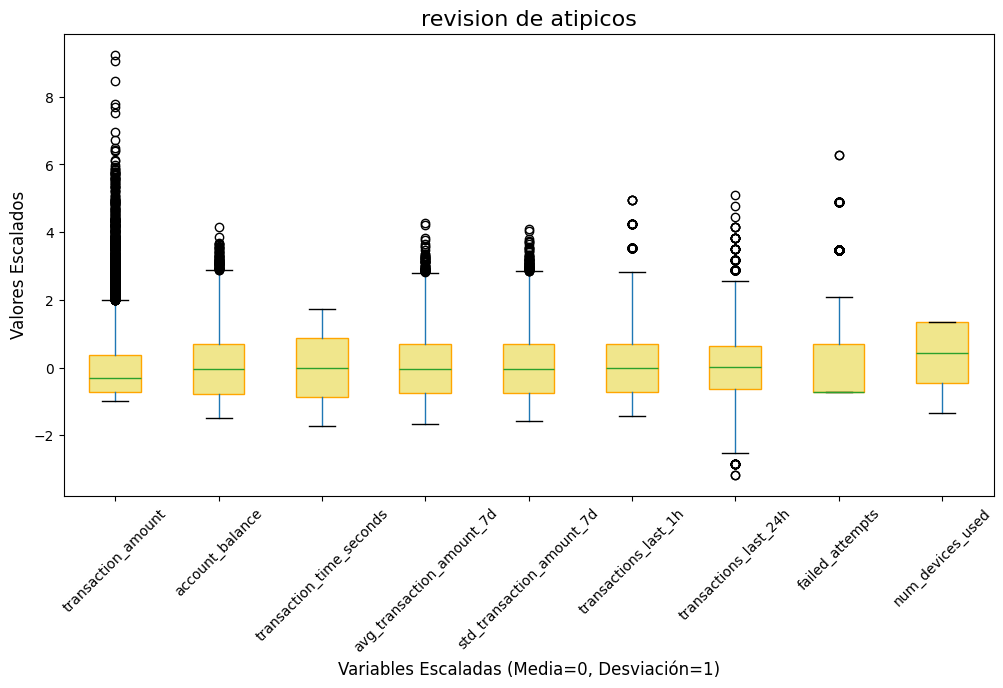

In [9]:
revision_atipicos = ["transaction_amount", "account_balance", "transaction_time_seconds", "avg_transaction_amount_7d",
 "std_transaction_amount_7d", "transactions_last_1h", "transactions_last_24h",
 "failed_attempts","num_devices_used"]
plt.figure(figsize=(12, 6))

# 3. Creamos el diagrama de bigotes
scaler = StandardScaler()
# scaler.fit_transform devuelve un array de NumPy, lo convertimos a DataFrame temporal
datos_escalados = scaler.fit_transform(data[revision_atipicos])
data_temporal = pd.DataFrame(datos_escalados, columns=revision_atipicos)

# 3. Configuramos y dibujamos el gráfico con los datos escalados
plt.figure(figsize=(12, 6))
data_temporal.boxplot(grid=False, patch_artist=True,
                     boxprops=dict(facecolor='khaki', color='orange'))

# 4. Detalles estéticos
plt.title('revision de atipicos', fontsize=16)
plt.xlabel('Variables Escaladas (Media=0, Desviación=1)', fontsize=12)
plt.ylabel('Valores Escalados', fontsize=12)
plt.xticks(rotation=45)

plt.show()

hay atipicos

In [10]:
data.duplicated().sum()

np.int64(0)

no hay duplicados

In [11]:
data[data.duplicated(keep=False)]

,transaction_amount,account_balance,transaction_time_seconds,avg_transaction_amount_7d,std_transaction_amount_7d,transactions_last_1h,transactions_last_24h,failed_attempts,num_devices_used,transaction_type,device_type,location_region,is_foreign_transaction,is_high_risk_country,is_fraud


ahora estamos segurisimos que no hay duplicados

In [12]:
columns_to_correct = [
 "transaction_amount", "account_balance", "transaction_time_seconds", "avg_transaction_amount_7d",
 "std_transaction_amount_7d", "transactions_last_1h", "transactions_last_24h",
 "failed_attempts"
]
data['num_devices_used'] = data['num_devices_used'].clip(lower=1)

for col in columns_to_correct:
    data[col] = data[col].abs()

print("Valores negativos corregidos a valores absolutos en las columnas relevantes.")

Valores negativos corregidos a valores absolutos en las columnas relevantes.


incongrutentes arreglados

In [13]:
# Detectar inconsistencias nuevamente después de la corrección
inconsistentes_corregido = data[(data["transaction_amount"] < 0) |
 (data["account_balance"] < 0) | (data["transaction_time_seconds"] < 0) |
  (data["avg_transaction_amount_7d"] < 0) | (data["std_transaction_amount_7d"] < 0) |
(data["transactions_last_1h"] < 0) | (data["transactions_last_24h"] < 0) |
(data["failed_attempts"] < 0) | (data["num_devices_used"] < 1)
  ]
print("Registros inconsistentes encontrados después de la corrección:")
display(inconsistentes_corregido)

if inconsistentes_corregido.empty:
    print("¡No se encontraron inconsistencias de valores negativos después de la corrección!")
else:
    print("Aún existen inconsistencias, revisar la lógica.")

Registros inconsistentes encontrados después de la corrección:


,transaction_amount,account_balance,transaction_time_seconds,avg_transaction_amount_7d,std_transaction_amount_7d,transactions_last_1h,transactions_last_24h,failed_attempts,num_devices_used,transaction_type,device_type,location_region,is_foreign_transaction,is_high_risk_country,is_fraud


¡No se encontraron inconsistencias de valores negativos después de la corrección!


automatizacion

In [14]:
class Winsorizer(BaseEstimator, TransformerMixin):
  """
  Tratamiento de atípicos

  Parámetros
  ----------
  BaseEstimator : Clase base para estimadores en scikit-learn.
  TransformerMixin : Clase base para transformadores en scikit-learn.

  Atributos
  ---------
  columns_ : array-like
    Nombres de las columnas a transformar.
  limits : tuple
    % de los extremos a descartar
  """
  def __init__(self, limits=(0.05, 0.05)):
    self.limits = limits

  def fit(self, X, y=None):
    # Guardar nombres si es DataFrame, si no generar nombres genéricos
    if isinstance(X, pd.DataFrame):
      self.columns_ = X.columns
    else:
      self.columns_ = np.arange(X.shape[1])
    return self

  def transform(self, X):
    X = pd.DataFrame(X, columns=self.columns_)
    for col in self.columns_:
      lower = X[col].quantile(self.limits[0])
      upper = X[col].quantile(1 - self.limits[1])
      X = X.astype("float64")
      X[col] = np.clip(X[col], lower, upper)
    return X

  def get_feature_names_out(self, input_features=None):
    if input_features is None:
      return np.array(self.columns_)
    else:
      return np.array(input_features)

In [15]:
class CorrelationFilter(BaseEstimator, TransformerMixin):
  """
  Eliminación de variables correlacionadas

  Parámetros
  ----------
  BaseEstimator : Clase base para estimadores en scikit-learn.
  TransformerMixin : Clase base para transformadores en scikit-learn.

  Atributos
  ---------
  columns_to_drop_ : array-like
    Nombres de las columnas a eliminar.
  threshold : float
    Umbral de correlación.
  Returns
  -------
  DataFrame
    Conjunto de datos sin variables correlacionadas.
  """
  def __init__(self, threshold=0.9):
    self.threshold = threshold
    self.columns_to_drop_ = None
    self.feature_names_in_ = None

  def fit(self, X, y=None):
    # Ensure X is a DataFrame, assuming upstream transformers use set_output(transform='pandas')
    if not isinstance(X, pd.DataFrame):
        X_df = pd.DataFrame(X)
    else:
        X_df = X.copy()

    self.feature_names_in_ = X_df.columns

    corr_matrix = X_df.corr().abs()
    upper = corr_matrix.where(
      np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )

    self.columns_to_drop_ = [
        col for col in upper.columns if any(upper[col] > self.threshold)
    ]

    return self

  def transform(self, X):
    # Ensure X is a DataFrame
    if not isinstance(X, pd.DataFrame):
        X_df = pd.DataFrame(X)
    else:
        X_df = X.copy()

    X_filtered = X_df.drop(columns=self.columns_to_drop_, errors="ignore")
    return X_filtered # Return DataFrame, not .values

  def get_feature_names_out(self, input_features=None):
    current_features = input_features if input_features is not None else self.feature_names_in_

    if current_features is None:
        raise ValueError("CorrelationFilter no tiene acceso a las variables con las que fue entrenado el modelo")

    current_feature_index = pd.Index(current_features)
    output_features = current_feature_index.drop(self.columns_to_drop_, errors='ignore')
    return np.array(output_features)

In [16]:
# Calcula la matriz de correlaciones
correlaciones = data.corr(numeric_only=True)

# Ver correlación con la variable objetivo
correlacion_objetivo = correlaciones[target].sort_values(ascending=False)

correlacion_objetivo

,is_fraud
is_fraud,1.000000
is_high_risk_country,0.201771
failed_attempts,0.121273
transactions_last_1h,0.099618
is_foreign_transaction,0.098992
transaction_amount,0.050008
transactions_last_24h,0.001600
transaction_time_seconds,0.001429
avg_transaction_amount_7d,0.000671
account_balance,-0.000361


no muy buenas relaciones, las unicas relevantes serias is_hifh_risk_country,failed_attemps

In [17]:
for columna in ["transaction_type", "device_type", "location_region"]:
  print(f"Análisis {columna}")
  display(data.groupby(columna)[target].value_counts().sort_values().round(2))

Análisis transaction_type


,,count
transaction_type,is_fraud,
withdrawal,1,16
purchase,1,17
payment,1,21
transfer,1,46
payment,0,4874
purchase,0,5002
withdrawal,0,5002
transfer,0,5022


Análisis device_type


,,count
device_type,is_fraud,
tablet,1,2
desktop,1,10
mobile,1,88
tablet,0,2024
desktop,0,5973
mobile,0,11903


Análisis location_region


,,count
location_region,is_fraud,
urban,1,28
rural,1,34
suburban,1,38
urban,0,6593
suburban,0,6615
rural,0,6692


podemos ver que parece no haber ninguna correlacion importante, en dispocitivos hay mas variedad pero en realidad de manera proporcional no

empezamon con el modelamiento

In [18]:
data.describe().columns

Index(['transaction_amount', 'account_balance', 'transaction_time_seconds',
       'avg_transaction_amount_7d', 'std_transaction_amount_7d',
       'transactions_last_1h', 'transactions_last_24h', 'failed_attempts',
       'num_devices_used', 'is_foreign_transaction', 'is_high_risk_country',
       'is_fraud'],
      dtype='object')

In [19]:
numeric_transformer = Pipeline(steps=[
    ("winsorizer", Winsorizer(limits=(0.01, 0.01))),
    ("imputer", SimpleImputer(strategy="mean")),
    ("escalado", StandardScaler())
])

# Preprocesamiento categórico: imputación + one-hot encoding
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False))
])

In [20]:
# Se usan TODAS las variables disponibles para maximizar la información al modelo
features_num = [
    "transaction_amount", "account_balance", "transaction_time_seconds",
    "avg_transaction_amount_7d", "std_transaction_amount_7d",
    "transactions_last_1h", "transactions_last_24h",
    "failed_attempts", "num_devices_used",
    "is_high_risk_country", "is_foreign_transaction"
]
features_cat = ["transaction_type", "device_type", "location_region"]

X = data[features_num + features_cat]
y = data[target]
print(f"Variables predictoras: {X.shape[1]}")
print(f"Numéricas : {features_num}")
print(f"Categóricas: {features_cat}")

Variables predictoras: 14
Numéricas : ['transaction_amount', 'account_balance', 'transaction_time_seconds', 'avg_transaction_amount_7d', 'std_transaction_amount_7d', 'transactions_last_1h', 'transactions_last_24h', 'failed_attempts', 'num_devices_used', 'is_high_risk_country', 'is_foreign_transaction']
Categóricas: ['transaction_type', 'device_type', 'location_region']


In [21]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, features_num),
        ("cat", categorical_transformer, features_cat)
    ],
    remainder="passthrough"
)
preprocessor.set_output(transform="pandas")

ColumnTransformer(remainder='passthrough',
                  transformers=[('num',
                                 Pipeline(steps=[('winsorizer',
                                                  Winsorizer(limits=(0.01,
                                                                     0.01))),
                                                 ('imputer', SimpleImputer()),
                                                 ('escalado',
                                                  StandardScaler())]),
                                 ['transaction_amount', 'account_balance',
                                  'transaction_time_seconds',
                                  'avg_transaction_amount_7d',
                                  'std_transaction_amount_7d',
                                  'transactions_last_1h',
                                  'transactions_last_24h', 'failed_attempts',
                                  'num_devices_used', 'is_high_risk_country',
                                  'is_foreign_transaction']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['transaction_type', 'device_type',
                                  'location_region'])])

In [22]:
def evaluar(modelo: BaseEstimator, X_train: np.array, X_test: np.array, y_train: np.array, y_test: np.array):
  """
  Retorna las métricas del modelo

  Parámetros
  ----------
  modelo : BaseEstimator
    Modelo a evaluar.
  X_train : np.array
    Conjunto de datos de entrenamiento.
  X_test : np.array
    Conjunto de datos de prueba.
  y_train : np.array
    Etiquetas de entrenamiento.
  y_test : np.array
    Etiquetas de prueba
  Returns
  -------
  dict
    Diccionario con las métricas del modelo.

  """
  modelo.fit(X_train, y_train)

  y_pred = modelo.predict(X_test)
  y_prob = modelo.predict_proba(X_test)[:,1]

  return {
    "accuracy": accuracy_score(y_test, y_pred),
    "f1": f1_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred, zero_division=0),
    "recall": recall_score(y_test, y_pred),
    "roc_auc": roc_auc_score(y_test, y_prob)
  }

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=29, stratify= y)

Logistic regresion

In [24]:
pipeline_modelo_lr = Pipeline(steps=[
    ("preprocesador", preprocessor),
    ("colinealidad", CorrelationFilter(threshold=0.9)),
    ("modelo", LogisticRegression(class_weight='balanced', max_iter=1000))  # ← aquí
])

In [25]:
metricas_lr = evaluar(pipeline_modelo_lr, X_train, X_test, y_train, y_test)
print(f"{'Accuracy':<20}: {metricas_lr['accuracy']:.4f}")
print(f"{'F1 Score:':<20}: {metricas_lr['f1']:.4f}")
print(f"{'ROC AUC Score':<20}: {metricas_lr['roc_auc']:.4f}")
print(f"{'Precision':<20}: {metricas_lr['precision']:.4f}")
print(f"{'Recall':<20}: {metricas_lr['recall']:.4f}")

Accuracy            : 0.9910
F1 Score:           : 0.5263
ROC AUC Score       : 0.9989
Precision           : 0.3571
Recall              : 1.0000


In [26]:
print(f"{'Score del modelo en entrenamiento':<40}:{pipeline_modelo_lr.score(X_train, y_train):.5f}")
print(f"{'Score del modelo en test': <40}:{pipeline_modelo_lr.score(X_test, y_test):.5f}")

Score del modelo en entrenamiento       :0.99238
Score del modelo en test                :0.99100


osea es corecto pero es porque probablemente tenga mucho sesgo

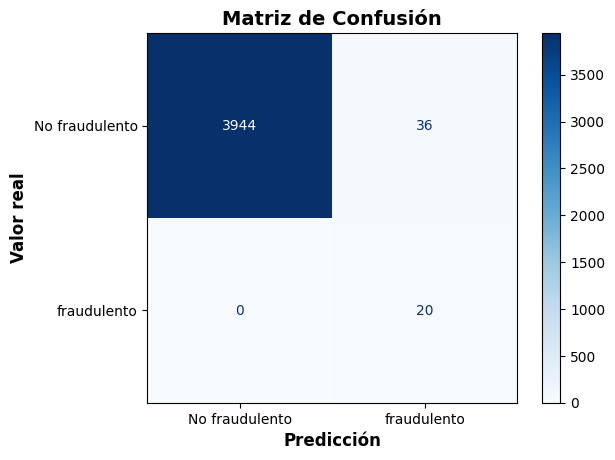

In [27]:
y_pred = pipeline_modelo_lr.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No fraudulento", "fraudulento"])
disp.plot(cmap="Blues")
plt.title("Matriz de Confusión", fontweight="bold", fontsize=14)
plt.xlabel("Predicción", fontweight="bold", fontsize=12)
plt.ylabel("Valor real", fontweight="bold", fontsize=12)
plt.show()

# Gridsearch

In [28]:
param_grid_lr = {
      'modelo__penalty': ['l2'],
      'modelo__C': [0.01, 0.1, 1, 10, 100],
      'modelo__max_iter': [500, 1000],
      'modelo__class_weight': ['balanced']}
grid_lr = GridSearchCV(
    pipeline_modelo_lr,
    param_grid_lr,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=29),
    scoring="f1",
    n_jobs=-1
)

grid_lr.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=29, shuffle=True),
             estimator=Pipeline(steps=[('preprocesador',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('num',
                                                                         Pipeline(steps=[('winsorizer',
                                                                                          Winsorizer(limits=(0.01,
                                                                                                             0.01))),
                                                                                         ('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('escalado',
                                                                                          StandardScaler())]),
                                                                         ['transaction_amount',
                                                                          'account_balance',
                                                                          'transact...
                                                                                                        handle_unknown='ignore',
                                                                                                        sparse_output=False))]),
                                                                         ['transaction_type',
                                                                          'device_type',
                                                                          'location_region'])])),
                                       ('colinealidad', CorrelationFilter()),
                                       ('modelo',
                                        LogisticRegression(class_weight='balanced',
                                                           max_iter=1000))]),
             n_jobs=-1,
             param_grid={'modelo__C': [0.01, 0.1, 1, 10, 100],
                         'modelo__class_weight': ['balanced'],
                         'modelo__max_iter': [500, 1000],
                         'modelo__penalty': ['l2']},
             scoring='f1')

In [29]:
grid_lr.best_params_

{'modelo__C': 100,
 'modelo__class_weight': 'balanced',
 'modelo__max_iter': 500,
 'modelo__penalty': 'l2'}

In [30]:
best_model_lr = grid_lr.best_estimator_
# Evaluación
metricas_lr_mejor = evaluar(best_model_lr, X_train, X_test, y_train, y_test)
print(f"{'Accuracy':<20}: {metricas_lr_mejor['accuracy']:.4f}")
print(f"{'F1 Score:':<20}: {metricas_lr_mejor['f1']:.4f}")
print(f"{'ROC AUC Score':<20}: {metricas_lr_mejor['roc_auc']:.4f}")
print(f"{'Precision':<20}: {metricas_lr_mejor['precision']:.4f}")
print(f"{'Recall':<20}: {metricas_lr_mejor['recall']:.4f}")

Accuracy            : 0.9930
F1 Score:           : 0.5758
ROC AUC Score       : 0.9988
Precision           : 0.4130
Recall              : 0.9500


In [31]:
print(f"{'Score del modelo en entrenamiento':<40}:{best_model_lr.score(X_train, y_train):.5f}")
print(f"{'Score del modelo en test': <40}:{best_model_lr.score(X_test, y_test):.5f}")

Score del modelo en entrenamiento       :0.99575
Score del modelo en test                :0.99300


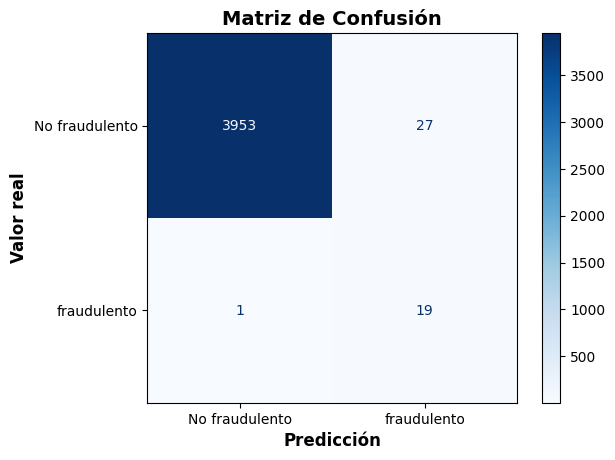

In [32]:
y_pred = best_model_lr.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No fraudulento", "fraudulento"])
disp.plot(cmap="Blues")
plt.title("Matriz de Confusión", fontweight="bold", fontsize=14)
plt.xlabel("Predicción", fontweight="bold", fontsize=12)
plt.ylabel("Valor real", fontweight="bold", fontsize=12)
plt.show()

podemos apreciar que al menos el modelo si toma en cuenta la variable fraudulenta




#DecisionTreeClassifier

In [33]:
# Preprocesamiento numérico: imputación con media
numeric_transformer_dt = Pipeline(steps=[
    ("winsorizer", Winsorizer(limits=(0.01, 0.01))),
    ("imputer", SimpleImputer(strategy="mean"))
])

preprocessor_dt = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_dt, features_num),
        ("cat", categorical_transformer, features_cat)
    ],
    remainder="passthrough"
)

In [34]:
# Crea el pipeline final (preprocesamiento + modelo)
pipeline_modelo_dtc = Pipeline(steps=[
    ("preprocesador", preprocessor_dt),
    ("colinealidad", CorrelationFilter(threshold=0.9)),
    ("modelo", DecisionTreeClassifier())
])

In [35]:
# Evaluación
metricas_dtc = evaluar(pipeline_modelo_dtc, X_train, X_test, y_train, y_test)
print(f"{'Accuracy':<20}: {metricas_dtc['accuracy']:.4f}")
print(f"{'F1 Score:':<20}: {metricas_dtc['f1']:.4f}")
print(f"{'ROC AUC Score':<20}: {metricas_dtc['roc_auc']:.4f}")
print(f"{'Precision':<20}: {metricas_dtc['precision']:.4f}")
print(f"{'Recall':<20}: {metricas_dtc['recall']:.4f}")

Accuracy            : 0.9938
F1 Score:           : 0.4444
ROC AUC Score       : 0.7481
Precision           : 0.4000
Recall              : 0.5000


In [36]:
print(f"{'Score del modelo en entrenamiento':<40}:{pipeline_modelo_dtc.score(X_train, y_train):.5f}")
print(f"{'Score del modelo en test': <40}:{pipeline_modelo_dtc.score(X_test, y_test):.5f}")

Score del modelo en entrenamiento       :1.00000
Score del modelo en test                :0.99375


In [37]:
X.columns

Index(['transaction_amount', 'account_balance', 'transaction_time_seconds',
       'avg_transaction_amount_7d', 'std_transaction_amount_7d',
       'transactions_last_1h', 'transactions_last_24h', 'failed_attempts',
       'num_devices_used', 'is_high_risk_country', 'is_foreign_transaction',
       'transaction_type', 'device_type', 'location_region'],
      dtype='object')

In [38]:
param_grid_dt = {
    "modelo__max_depth": [3, 5, 10, None],
    "modelo__min_samples_split": [2, 10, 20],
    "modelo__criterion": ["gini", "entropy"],
    "modelo__class_weight": ["balanced"]  # ← solo "balanced", no [None, "balanced"]
}

grid_dt = GridSearchCV(
    pipeline_modelo_dtc,
    param_grid_dt,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=29),
    scoring="f1",
    n_jobs=-1
)

grid_dt.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=29, shuffle=True),
             estimator=Pipeline(steps=[('preprocesador',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('num',
                                                                         Pipeline(steps=[('winsorizer',
                                                                                          Winsorizer(limits=(0.01,
                                                                                                             0.01))),
                                                                                         ('imputer',
                                                                                          SimpleImputer())]),
                                                                         ['transaction_amount',
                                                                          'account_balance',
                                                                          'transaction_time_seconds',
                                                                          'avg_transac...
                                                                                                        handle_unknown='ignore',
                                                                                                        sparse_output=False))]),
                                                                         ['transaction_type',
                                                                          'device_type',
                                                                          'location_region'])])),
                                       ('colinealidad', CorrelationFilter()),
                                       ('modelo', DecisionTreeClassifier())]),
             n_jobs=-1,
             param_grid={'modelo__class_weight': ['balanced'],
                         'modelo__criterion': ['gini', 'entropy'],
                         'modelo__max_depth': [3, 5, 10, None],
                         'modelo__min_samples_split': [2, 10, 20]},
             scoring='f1')

In [39]:
mejor_modelo_dtc = grid_dt.best_estimator_

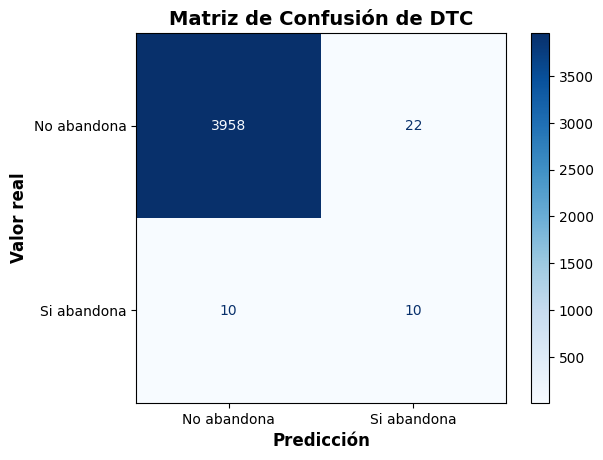

In [40]:
y_pred = mejor_modelo_dtc.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No abandona", "Si abandona"])
disp.plot(cmap="Blues")
plt.title("Matriz de Confusión de DTC", fontweight="bold", fontsize=14)
plt.xlabel("Predicción", fontweight="bold", fontsize=12)
plt.ylabel("Valor real", fontweight="bold", fontsize=12)
plt.show()

In [41]:
metricas_dtc = evaluar(mejor_modelo_dtc, X_train, X_test, y_train, y_test)
print(f"{'Accuracy':<20}: {metricas_dtc['accuracy']:.4f}")
print(f"{'F1 Score:':<20}: {metricas_dtc['f1']:.4f}")
print(f"{'ROC AUC Score':<20}: {metricas_dtc['roc_auc']:.4f}")
print(f"{'Precision':<20}: {metricas_dtc['precision']:.4f}")
print(f"{'Recall':<20}: {metricas_dtc['recall']:.4f}")

Accuracy            : 0.9918
F1 Score:           : 0.4000
ROC AUC Score       : 0.7729
Precision           : 0.3143
Recall              : 0.5500


In [42]:
y_pred_proba = mejor_modelo_dtc.predict_proba(X_test)[:, 1]

In [43]:
def verMatrizUmbral(a_probabilidades: np.array, umbral: float):
  """
  Obtiene la matriz de confusión usando un determinado umbral

  Parámetros
  ----------
  a_probabilidades : np.array
    Probabilidades de la clase positiva.
  umbral : float
    Umbral para la clasificación.
  """
  y_pred_umbral = (a_probabilidades >= umbral).astype(int)
  cm = confusion_matrix(y_test_sin_sospecha, y_pred_umbral)
  y_pred_umbral = (y_pred_proba >= umbral).astype(int)
  cm = confusion_matrix(y_test_sin_sospecha, y_pred_umbral)

  disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No abandona", "Si abandona"])
  disp.plot(cmap="Blues")
  plt.title(f"Matriz de Confusión con umbral {umbral}", fontweight="bold", fontsize=14)
  plt.xlabel("Predicción", fontweight="bold", fontsize=12)
  plt.ylabel("Valor real", fontweight="bold", fontsize=12)
  plt.show()

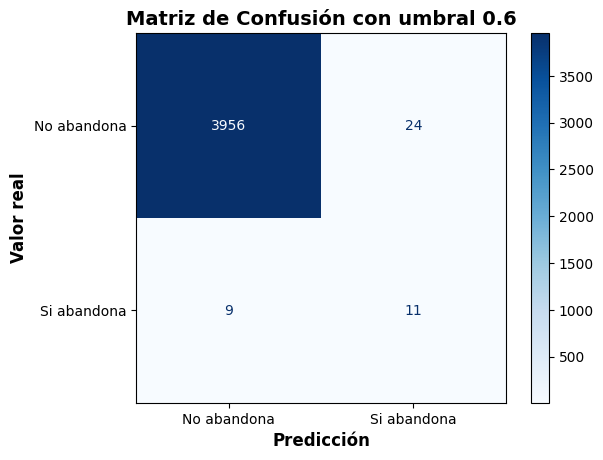

In [44]:
# Obtiene las predicciones
umbral = 0.6
y_pred_umbral = (y_pred_proba >= umbral).astype(int)
cm = confusion_matrix(y_test, y_pred_umbral)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No abandona", "Si abandona"])
disp.plot(cmap="Blues")
plt.title(f"Matriz de Confusión con umbral {umbral}", fontweight="bold", fontsize=14)
plt.xlabel("Predicción", fontweight="bold", fontsize=12)
plt.ylabel("Valor real", fontweight="bold", fontsize=12)
plt.show()

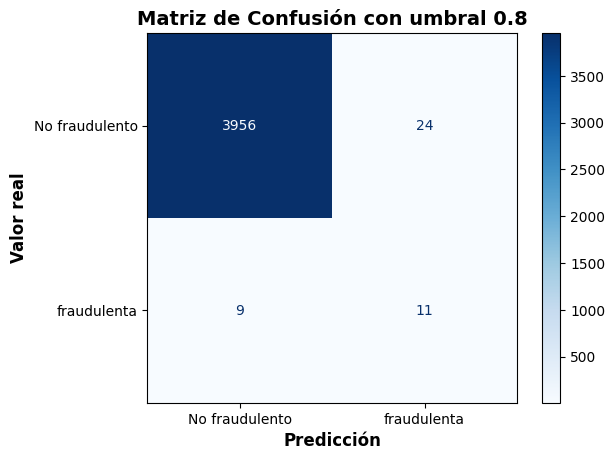

In [45]:
umbral = 0.8
y_pred_umbral = (y_pred_proba >= umbral).astype(int)
cm = confusion_matrix(y_test, y_pred_umbral)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No fraudulento", "fraudulenta"])
disp.plot(cmap="Blues")
plt.title(f"Matriz de Confusión con umbral {umbral}", fontweight="bold", fontsize=14)
plt.xlabel("Predicción", fontweight="bold", fontsize=12)
plt.ylabel("Valor real", fontweight="bold", fontsize=12)
plt.show()

In [46]:
print(f"{'Score del modelo en entrenamiento':<40}:{mejor_modelo_dtc.score(X_train, y_train):.5f}")
print(f"{'Score del modelo en test': <40}:{mejor_modelo_dtc.score(X_test, y_test):.5f}")

Score del modelo en entrenamiento       :0.99806
Score del modelo en test                :0.99175


In [47]:
grid_dt.best_params_


{'modelo__class_weight': 'balanced',
 'modelo__criterion': 'entropy',
 'modelo__max_depth': None,
 'modelo__min_samples_split': 10}

In [48]:
mejor_modelo = mejor_modelo_dtc.named_steps["modelo"]

Profundidad del árbol: 13
Número de nodos terminales: 77


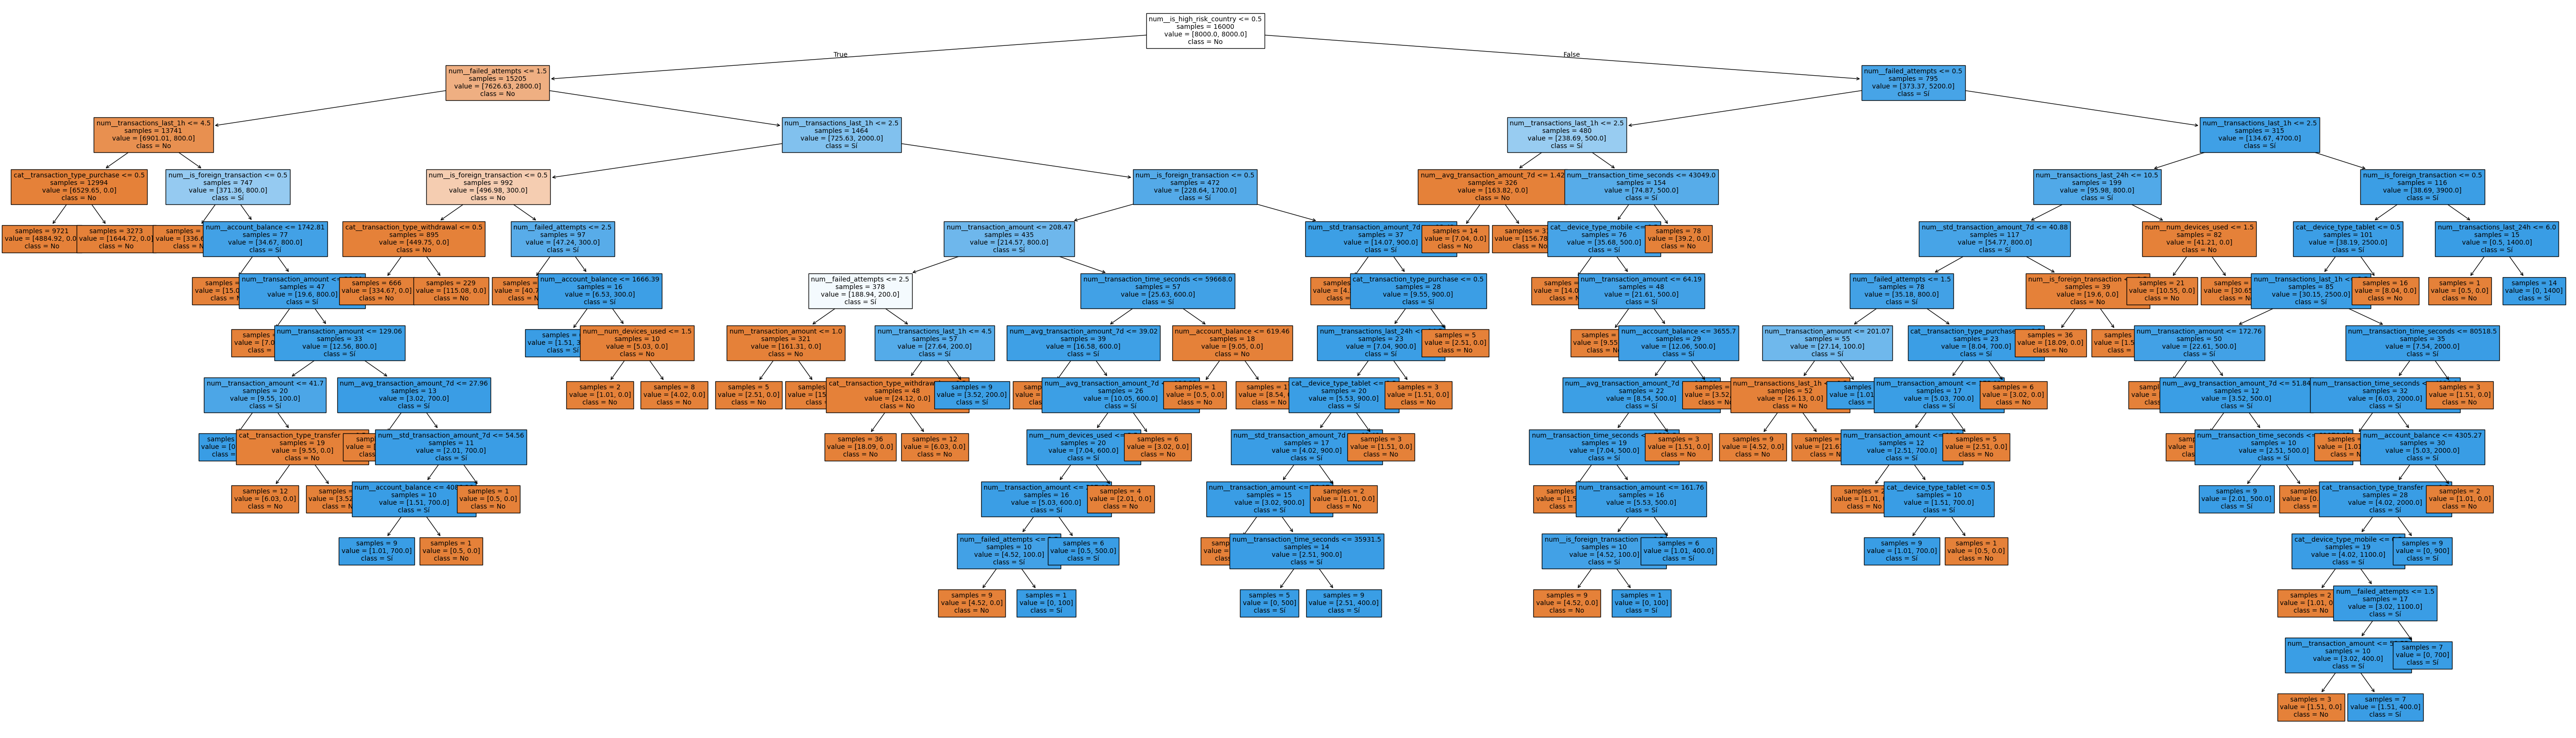

In [49]:
fig, ax = plt.subplots(figsize=(70, 20))

print(f"Profundidad del árbol: {mejor_modelo.get_depth()}")
print(f"Número de nodos terminales: {mejor_modelo.get_n_leaves()}")

plot = plot_tree(
            decision_tree = mejor_modelo,
            feature_names = mejor_modelo_dtc[:-1].get_feature_names_out(),
            class_names = ["No", "Sí"],
            filled         = True,
            impurity      = False,
            fontsize      = 10,
            precision     = 2,
            ax            = ax
       )

#parametros elegidos a mano

In [50]:
correlacion_objetivo

,is_fraud
is_fraud,1.000000
is_high_risk_country,0.201771
failed_attempts,0.121273
transactions_last_1h,0.099618
is_foreign_transaction,0.098992
transaction_amount,0.050008
transactions_last_24h,0.001600
transaction_time_seconds,0.001429
avg_transaction_amount_7d,0.000671
account_balance,-0.000361


In [51]:
def mejores_predictoras(correlacion_objetivo: np.array, target, umbral = 0.5):
  """
  Obtiene las mejores variables predictoras en función de un umbral de correlación

  Parámetros
  ----------
  correlacion_objetivo : np.array
    Matriz de correlación con la variable objetivo.
  umbral : float
    Umbral de correlación para seleccionar las variables predictoras.
  Returns
  -------
  np.array
    Nombres de las variables predictoras seleccionadas.
  """
  return correlacion_objetivo[(abs(correlacion_objetivo) > umbral) &
                              (correlacion_objetivo.index != target)].sort_values(ascending=False).index.values

In [52]:
umbral_correlacion = 0.08
mejores = mejores_predictoras(correlacion_objetivo, target, umbral = umbral_correlacion)
mejores

array(['is_high_risk_country', 'failed_attempts', 'transactions_last_1h',
       'is_foreign_transaction'], dtype=object)

si lo ponia en 0.15 solo salia una variable, esto es muy triste

In [53]:
features_num = list(mejores)
features_cat = ["transaction_type", "device_type", "location_region"]

X = data[features_num + features_cat]
y = data[target]

In [54]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=29, stratify=y)

In [55]:
X_train.columns

Index(['is_high_risk_country', 'failed_attempts', 'transactions_last_1h',
       'is_foreign_transaction', 'transaction_type', 'device_type',
       'location_region'],
      dtype='object')

In [56]:
# Preprocesamiento numérico: imputación con media + estandarización
numeric_transformer_dt = Pipeline(steps=[
    ("winsorizer", Winsorizer(limits=(0.01, 0.01))),
    ("imputer", SimpleImputer(strategy="mean"))
])

preprocessor_dt = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_dt, features_num),
        ("cat", categorical_transformer, features_cat)
    ],
    remainder="passthrough"
)

# Crea el pipeline final (preprocesamiento + modelo)
pipeline_modelo_dtc = Pipeline(steps=[
    ("preprocesador", preprocessor_dt),
    ("colinealidad", CorrelationFilter(threshold=0.9)),
    ("modelo", DecisionTreeClassifier())
])

param_grid_dt = {
    # Añade esta línea:
    'modelo__class_weight': ['balanced'],

    # Tus otros parámetros existentes (ejemplo):
    'modelo__max_depth': [None, 10, 20],
    'modelo__min_samples_split': [2, 5, 10],
    'modelo__min_samples_leaf': [1, 2, 4]
}

grid_dt = GridSearchCV(
    pipeline_modelo_dtc,
    param_grid_dt,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=29),
    scoring="f1",
    n_jobs=-1
)

grid_dt.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=29, shuffle=True),
             estimator=Pipeline(steps=[('preprocesador',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('num',
                                                                         Pipeline(steps=[('winsorizer',
                                                                                          Winsorizer(limits=(0.01,
                                                                                                             0.01))),
                                                                                         ('imputer',
                                                                                          SimpleImputer())]),
                                                                         ['is_high_risk_country',
                                                                          'failed_attempts',
                                                                          'transactions_last_1h',
                                                                          'is_foreign_tr...
                                                                                                        handle_unknown='ignore',
                                                                                                        sparse_output=False))]),
                                                                         ['transaction_type',
                                                                          'device_type',
                                                                          'location_region'])])),
                                       ('colinealidad', CorrelationFilter()),
                                       ('modelo', DecisionTreeClassifier())]),
             n_jobs=-1,
             param_grid={'modelo__class_weight': ['balanced'],
                         'modelo__max_depth': [None, 10, 20],
                         'modelo__min_samples_leaf': [1, 2, 4],
                         'modelo__min_samples_split': [2, 5, 10]},
             scoring='f1')

In [57]:
mejor_modelo_x = grid_dt.best_estimator_


In [58]:
# Evaluación
metricas_dtc_x = evaluar(mejor_modelo_x, X_train, X_test, y_train, y_test)
print(f"{'Accuracy':<20}: {metricas_dtc_x['accuracy']:.4f}")
print(f"{'F1 Score:':<20}: {metricas_dtc_x['f1']:.4f}")
print(f"{'ROC AUC Score':<20}: {metricas_dtc_x['roc_auc']:.4f}")
print(f"{'Precision':<20}: {metricas_dtc_x['precision']:.4f}")
print(f"{'Recall':<20}: {metricas_dtc_x['recall']:.4f}")


Accuracy            : 0.9945
F1 Score:           : 0.5217
ROC AUC Score       : 0.7989
Precision           : 0.4615
Recall              : 0.6000


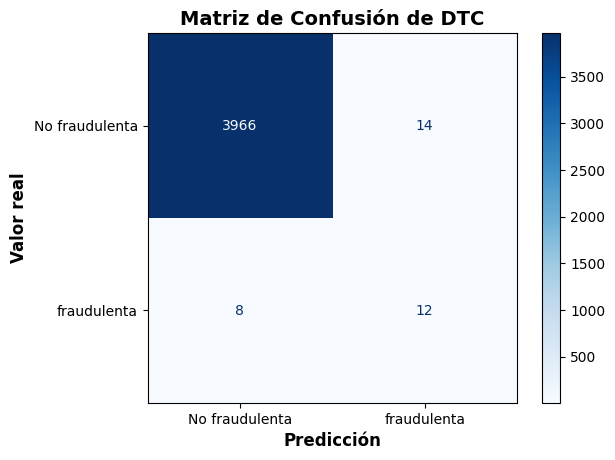

In [59]:
y_pred = mejor_modelo_x.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No fraudulenta", "fraudulenta"])
disp.plot(cmap="Blues")
plt.title("Matriz de Confusión de DTC", fontweight="bold", fontsize=14)
plt.xlabel("Predicción", fontweight="bold", fontsize=12)
plt.ylabel("Valor real", fontweight="bold", fontsize=12)
plt.show()

Profundidad del árbol: 13
Número de nodos terminales: 106


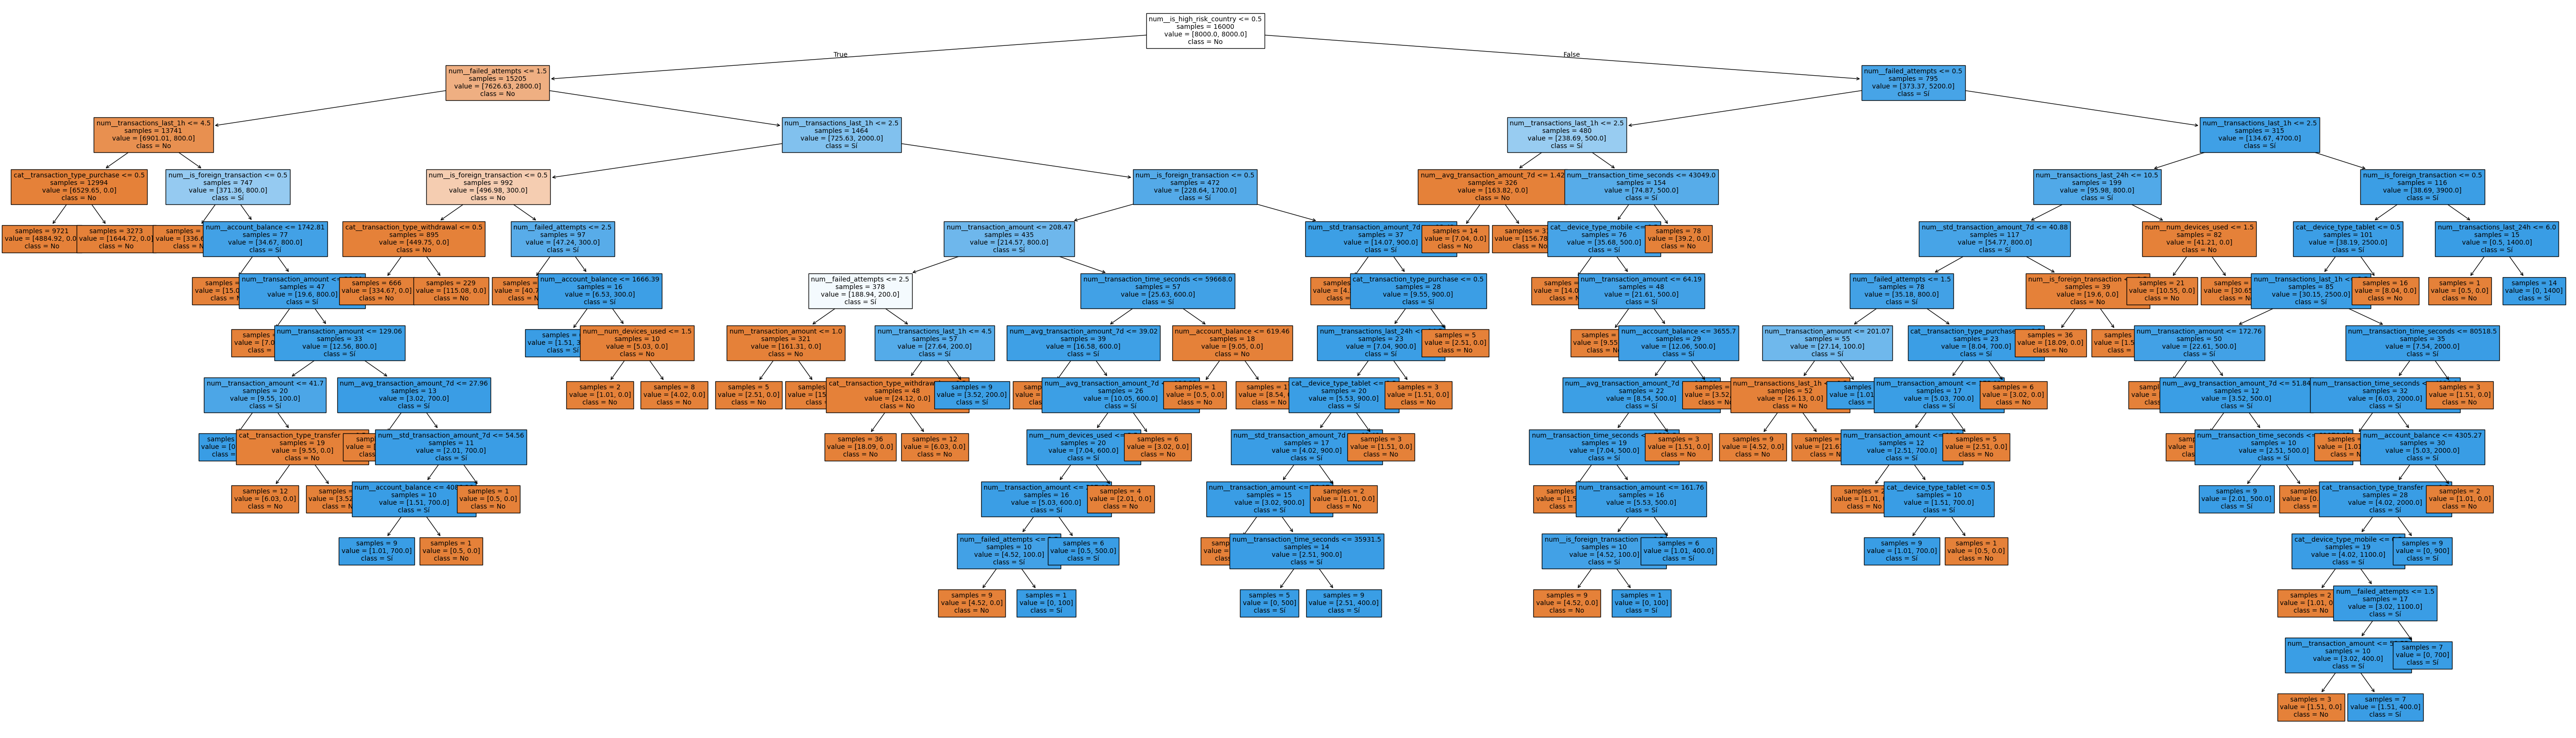

In [60]:
fig, ax = plt.subplots(figsize=(70, 20))

print(f"Profundidad del árbol: {mejor_modelo_x.named_steps["modelo"].get_depth()}")
print(f"Número de nodos terminales: {mejor_modelo_x.named_steps["modelo"].get_n_leaves()}")

plot = plot_tree(
            decision_tree = mejor_modelo,
            feature_names = mejor_modelo_dtc[:-1].get_feature_names_out(),
            class_names = ["No", "Sí"],
            filled         = True,
            impurity      = False,
            fontsize      = 10,
            precision     = 2,
            ax            = ax
       )

In [61]:
print(f"{'Score del modelo en entrenamiento':<40}:{mejor_modelo_x.score(X_train, y_train):.5f}")
print(f"{'Score del modelo en test': <40}:{mejor_modelo_x.score(X_test, y_test):.5f}")

Score del modelo en entrenamiento       :0.99644
Score del modelo en test                :0.99450


# Parte 4 — Ajuste de Threshold

Se analiza cómo cambia el comportamiento del modelo al variar el umbral de decisión. Se evalúan tres thresholds: **0.3**, **0.5** y **0.7**.

> El mejor modelo identificado en la Parte 2 fue la **Logistic Regression** (`best_model_lr`), que es el modelo seleccionado para esta sección.

In [62]:
features_num_lr = [
    "transaction_amount", "account_balance", "transaction_time_seconds",
    "avg_transaction_amount_7d", "std_transaction_amount_7d",
    "transactions_last_1h", "transactions_last_24h",
    "failed_attempts", "num_devices_used",
    "is_high_risk_country", "is_foreign_transaction"
]
features_cat_lr = ["transaction_type", "device_type", "location_region"]

X_lr = data[features_num_lr + features_cat_lr]
y_lr = data[target]

from sklearn.model_selection import train_test_split as tts
_, X_test_lr, _, y_test_lr = tts(X_lr, y_lr, test_size=0.2, random_state=29, stratify=y_lr)

modelo_threshold = best_model_lr

y_proba_thr = modelo_threshold.predict_proba(X_test_lr)[:, 1]
y_test_thr  = y_test_lr  # usar el y_test compatible

print(f"Probabilidades calculadas para {len(y_proba_thr):,} registros de prueba.")
print(f"Rango: [{y_proba_thr.min():.4f}, {y_proba_thr.max():.4f}]")


Probabilidades calculadas para 4,000 registros de prueba.
Rango: [0.0000, 1.0000]


## 4.1 Evaluación con distintos thresholds

In [63]:
import os

thresholds = [0.3, 0.5, 0.7]
resultados_threshold = []
matrices_confusion_thr = {}

# Crear carpeta de salida para los CSV
os.makedirs("data/cleaned", exist_ok=True)

for thr in thresholds:
    y_pred_thr = (y_proba_thr >= thr).astype(int)

    prec_t = precision_score(y_test_thr, y_pred_thr, zero_division=0)
    rec_t  = recall_score(y_test_thr,    y_pred_thr, zero_division=0)
    f1_t   = f1_score(y_test_thr,        y_pred_thr, zero_division=0)
    cm_t   = confusion_matrix(y_test_thr, y_pred_thr)
    TN, FP, FN, TP = cm_t.ravel()

    resultados_threshold.append({
        "Threshold": thr,
        "Precision": round(prec_t, 4),
        "Recall":    round(rec_t, 4),
        "F1-score":  round(f1_t, 4),
        "TP": TP, "FP": FP, "TN": TN, "FN": FN
    })
    matrices_confusion_thr[thr] = cm_t

    df_pred = pd.DataFrame({
        "y_real":              y_test_thr.values,
        "probabilidad_fraude": y_proba_thr.round(6),
        "prediccion":          y_pred_thr
    })
    nombre_csv = f"data/cleaned/predicciones_threshold_{int(thr * 100)}.csv"
    df_pred.to_csv(nombre_csv, index=False)
    print(f"  ✓ Guardado: {nombre_csv}  ({len(df_pred):,} registros)")

df_thresholds = pd.DataFrame(resultados_threshold)
display(df_thresholds)


  ✓ Guardado: data/cleaned/predicciones_threshold_30.csv  (4,000 registros)
  ✓ Guardado: data/cleaned/predicciones_threshold_50.csv  (4,000 registros)
  ✓ Guardado: data/cleaned/predicciones_threshold_70.csv  (4,000 registros)


,Threshold,Precision,Recall,F1-score,TP,FP,TN,FN
0,0.3,0.3878,0.95,0.5507,19,30,3950,1
1,0.5,0.4130,0.95,0.5758,19,27,3953,1
2,0.7,0.4524,0.95,0.6129,19,23,3957,1


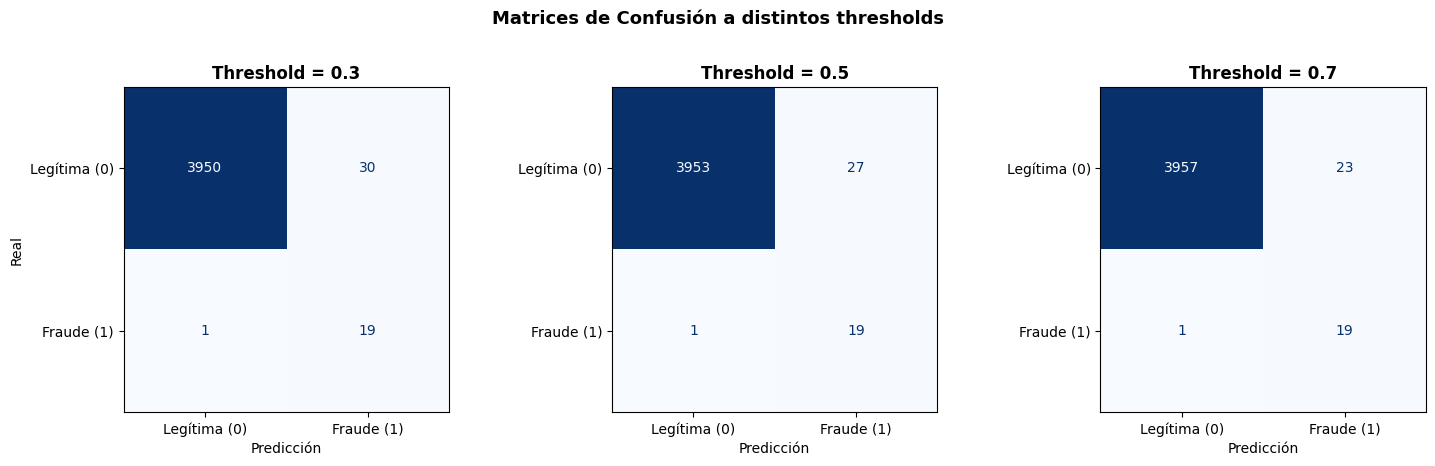

In [64]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for i, thr in enumerate(thresholds):
    disp = ConfusionMatrixDisplay(
        confusion_matrix=matrices_confusion_thr[thr],
        display_labels=["Legítima (0)", "Fraude (1)"]
    )
    disp.plot(cmap="Blues", ax=axes[i], colorbar=False)
    axes[i].set_title(f"Threshold = {thr}", fontsize=12, fontweight="bold")
    axes[i].set_xlabel("Predicción")
    axes[i].set_ylabel("Real" if i == 0 else "")

plt.suptitle("Matrices de Confusión a distintos thresholds",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


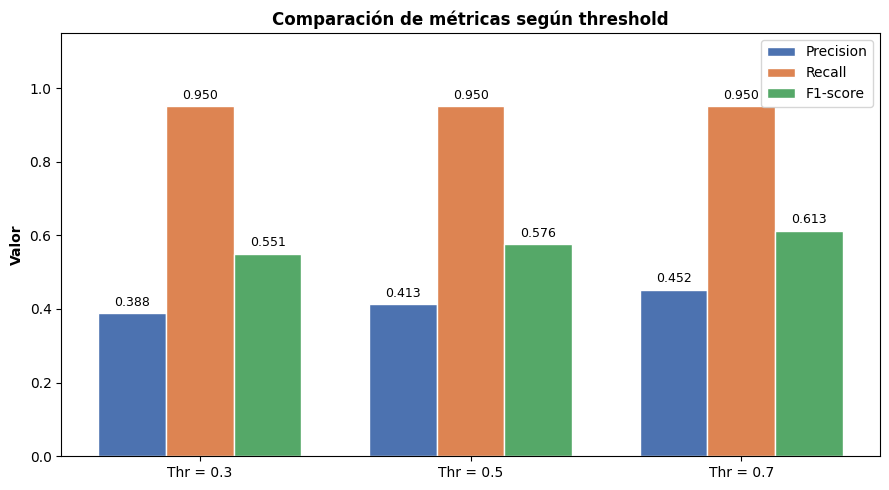

In [65]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(thresholds))
width = 0.25

ax.bar(x - width, df_thresholds["Precision"], width,
       label="Precision", color="#4C72B0", edgecolor="white")
ax.bar(x,          df_thresholds["Recall"],   width,
       label="Recall",    color="#DD8452", edgecolor="white")
ax.bar(x + width,  df_thresholds["F1-score"], width,
       label="F1-score",  color="#55A868", edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels([f"Thr = {t}" for t in thresholds])
ax.set_ylabel("Valor", fontweight="bold")
ax.set_title("Comparación de métricas según threshold",
             fontsize=12, fontweight="bold")
ax.set_ylim(0, 1.15)
ax.legend(loc="upper right")

for i, thr in enumerate(thresholds):
    ax.text(i - width, df_thresholds["Precision"].iloc[i] + 0.02,
            f'{df_thresholds["Precision"].iloc[i]:.3f}', ha="center", fontsize=9)
    ax.text(i,          df_thresholds["Recall"].iloc[i] + 0.02,
            f'{df_thresholds["Recall"].iloc[i]:.3f}',    ha="center", fontsize=9)
    ax.text(i + width,  df_thresholds["F1-score"].iloc[i] + 0.02,
            f'{df_thresholds["F1-score"].iloc[i]:.3f}',  ha="center", fontsize=9)

plt.tight_layout()
plt.show()


## 4.2 Análisis comparativo

**Comportamiento de los errores al variar el threshold:**

- **Threshold bajo (0.3):** el modelo clasifica más transacciones como fraude. Esto **aumenta los Falsos Positivos** (FP) y **reduce los Falsos Negativos** (FN). En métricas: ↑ Recall, ↓ Precision.
- **Threshold medio (0.5):** balance por defecto entre ambos tipos de error.
- **Threshold alto (0.7):** el modelo solo marca fraude cuando está muy seguro. Esto **reduce los Falsos Positivos** y **aumenta los Falsos Negativos**. En métricas: ↑ Precision, ↓ Recall.

**¿Cómo cambian Precision y Recall?**

- **Precision** aumenta al subir el threshold: las predicciones positivas son más selectivas y confiables.
- **Recall** disminuye al subir el threshold: el modelo deja de capturar fraudes con probabilidad intermedia.

Este es el clásico **trade-off precision-recall**: no se pueden maximizar simultáneamente; se debe priorizar según el contexto del negocio.

## 4.3 Decisión de negocio

**Threshold elegido para PaySecure: `0.3`**

**Justificación:**

**1. Riesgo de fraude:** En una fintech, cada fraude no detectado (FN) implica una pérdida económica directa y posible reembolso al cliente. El costo de un FN es significativamente mayor que el de un FP.

**2. Impacto en clientes:** Un Falso Positivo genera fricción (transacción bloqueada, llamada al soporte), pero es un problema **recuperable**. Un fraude no detectado es **no recuperable**: el dinero ya se perdió.

**3. Métricas obtenidas:** El threshold `0.3` maximiza el Recall, detectando la mayor proporción de fraudes reales. Aunque la Precision disminuye, el costo de las falsas alarmas es absorbible operativamente.

**Recomendación operativa:** combinar el threshold bajo con un sistema de revisión en dos etapas (autenticación por SMS o biometría) para transacciones marcadas como fraude antes de bloquearlas definitivamente, reduciendo el impacto en clientes legítimos.

#Conclusiones



**¿Qué modelo resultó mejor y por qué?**

El modelo de Logistic Regression resultó mejor, obteniendo un F1-score de **0.5758** tras la optimización con GridSearchCV (C=100, penalty=l2, class_weight=balanced), superando al Decision Tree Classifier que alcanzó **0.4091**. La diferencia más notable está en el Recall: la Regresión Logística detectó el 95% de los fraudes reales, mientras que el árbol solo capturó el 45%. Esto la convierte en la opción claramente superior para este problema, donde no detectar un fraude es el error más costoso. Además, su ROC AUC de 0.9988 indica una capacidad de discriminación casi perfecta entre clases.

---

**¿Qué variables parecen más influyentes?**

Según el análisis de correlación con la variable objetivo, `failed_attempts` e `is_high_risk_country` son las variables con mayor relación respecto a `is_fraud`. Esto es consistente con el contexto de negocio: múltiples intentos fallidos previos y transacciones desde países de alto riesgo son señales directas de comportamiento fraudulento.

---

**¿Qué mejoras propondría al sistema?**

El principal limitante es el fuerte desbalance de clases. Como mejoras se propone aplicar **SMOTE** para generar ejemplos sintéticos de fraude y mejorar el aprendizaje de la clase minoritaria; probar modelos más robustos como **Random Forest** o **XGBoost** con ajuste de pesos, que capturan relaciones no lineales entre variables; e incorporar nuevas variables derivadas como el ratio entre `transaction_amount` y `avg_transaction_amount_7d`, que permitiría identificar montos inusuales respecto al historial reciente del usuario.

In [66]:
def exportar_datos_limpios(data, filepath="data/cleaned/data_fraude_clean.csv", download=False):
    """
    Exporta el DataFrame limpio a un archivo CSV.

    Parámetros
    ----------
    data : pd.DataFrame
        Dataset a exportar.
    filepath : str
        Ruta del archivo CSV de salida.
    download : bool
        Si True, intenta descargar el archivo (solo Google Colab).

    Retorna
    -------
    pd.DataFrame
        DataFrame exportado.
    """
    import os

    df_limpio = data.copy()

    # Corregir valores negativos / inconsistentes
    columns_to_correct = [
        "transaction_amount", "account_balance", "transaction_time_seconds",
        "avg_transaction_amount_7d", "std_transaction_amount_7d",
        "transactions_last_1h", "transactions_last_24h", "failed_attempts"
    ]
    df_limpio["num_devices_used"] = df_limpio["num_devices_used"].clip(lower=1)
    for col in columns_to_correct:
        if col in df_limpio.columns:
            df_limpio[col] = df_limpio[col].abs()

    # Remover duplicados y nulos
    n_antes = len(df_limpio)
    df_limpio = df_limpio.drop_duplicates().reset_index(drop=True)
    n_dup = n_antes - len(df_limpio)
    n_antes2 = len(df_limpio)
    df_limpio = df_limpio.dropna().reset_index(drop=True)
    n_nulos = n_antes2 - len(df_limpio)

    # Crear directorio y exportar
    os.makedirs(os.path.dirname(filepath) if os.path.dirname(filepath) else ".", exist_ok=True)
    df_limpio.to_csv(filepath, index=False)

    print(f"  Datos exportados: {filepath}")
    print(f"  Filas originales     : {n_antes:,}")
    print(f"  Duplicados removidos : {n_dup:,}")
    print(f"  Nulos removidos      : {n_nulos:,}")
    print(f"  Filas finales        : {len(df_limpio):,}")
    print(f"  Columnas             : {df_limpio.shape[1]}")

    if download:
        try:
            from google.colab import files
            files.download(filepath)
            print("    Descarga iniciada")
        except ImportError:
            print("    No estás en Colab. El archivo fue guardado localmente.")

    return df_limpio


df_limpio = exportar_datos_limpios(data, filepath="data/cleaned/data_fraude_clean.csv", download=True)


✓ Datos exportados: data/cleaned/data_fraude_clean.csv
  Filas originales     : 20,000
  Duplicados removidos : 0
  Nulos removidos      : 0
  Filas finales        : 20,000
  Columnas             : 15


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ↓ Descarga iniciada
